# Ocean Acidification Extreme calculation 

Using this notebook to compute OAX diagnostics (duration and mean magnitude)

Using papermill1 to run in batch and can be applied to the prescribed oax_var passed to routine.

Applied to the OFAM future simulation with statics compute for various GWLs

Did the calculations with megamem 


In [1]:
import xarray as xr
from dask.distributed import Client
import dask.array as da
from dask import delayed
import numpy as np
import os
import matplotlib.pyplot as plt
from glob import glob
import warnings
# importing sys
import sys

import dask
# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

In [2]:
client = Client()
client

2025-10-09 19:16:36,687 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-10-09 19:16:36,691 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-10-09 19:16:36,836 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0057.gadi.nci.org.au/49448/proxy/8787/status,
Dashboard: /node/gadi-cpu-bdw-0057.gadi.nci.org.au/49448/proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41027,Workers: 28
Dashboard: /node/gadi-cpu-bdw-0057.gadi.nci.org.au/49448/proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46167,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0057.gadi.nci.org.au/49448/proxy/38527/status,Memory: 0 B
Nanny: tcp://127.0.0.1:35651,


In [3]:
def drop_stuff(ds, coords_to_drop, vars_to_drop):
    ds = ds.drop_vars(coords_to_drop, errors='ignore')
    ds = ds.drop_vars(vars_to_drop, errors='ignore')
    return ds

In [4]:
def load_data1(oax_var, coords_to_drop, vars_to_drop, pattern0, pattern1, pattern2):

    dsst1 = xr.open_mfdataset(pattern0, parallel=True, preprocess=lambda x: drop_stuff(x, coords_to_drop, vars_to_drop)).squeeze()
    dsst2 = xr.open_mfdataset(pattern1 + pattern2, parallel=True, preprocess=lambda x: drop_stuff(x, coords_to_drop, vars_to_drop)).squeeze()
#rename coordinates!!
    dsst2 = dsst2.rename({"TIME11": "time","XT_OCEAN": "xt_ocean", "YT_OCEAN": "yt_ocean" })
    dsst1 = dsst1.rename({"TIME11": "time","XT_OCEAN": "xt_ocean", "YT_OCEAN": "yt_ocean" })

    sst = dsst2[oax_var]
    ssth= dsst1[oax_var]
    return sst,ssth

In [5]:
def calculate_heatwave_metrics(sst, threshold90, period, start, end):
    sst_period = sst.sel(time=slice(start, end))
    nshape = np.shape(sst_period)
    nyears = int(nshape[0] / 365.25 + .5)

    expanded_threshold = threshold90.sel(dayofyear=sst_period['time'].dt.dayofyear)
    expanded_threshold = expanded_threshold.drop('dayofyear')

    diff = sst_period - expanded_threshold

    min_dur = 10
    hmask = sst_period > expanded_threshold
    hmask1 = hmask.rolling(time=min_dur, center=False).sum() >= min_dur
    hmask2 = hmask1.shift(time=((min_dur-1)*-1), fill_value=False)
    hmask3 = hmask1 | hmask2

    dur_mhw = (hmask3.sum('time') / nyears)
    mag_mhw = ((hmask3 * diff).mean('time'))

    dur_mhw = dur_mhw.rename('duration').assign_attrs(units='days per year')
    mag_mhw = mag_mhw.rename('magnitude').assign_attrs(units='degrees Celsius')

    result = xr.merge([dur_mhw, mag_mhw])

    return result

In [6]:
def save_results(result_ds, period, oax_var):
    file_path = f"/g/data/ia39/ncra/ocean/{oax_var}_{period}_oax.nc"
    result_ds.to_netcdf(file_path)
    print(f"Saved results to {file_path}")

In [7]:
def process_all_periods1(GWL_periods, sst, ssth, oax_var, threshold90, threshold90h):
    for period, (start, end) in GWL_periods.items():
        if period == 'current':
            result_ds = calculate_heatwave_metrics(ssth, threshold90h, period, start, end).compute()
        else:
            result_ds = calculate_heatwave_metrics(sst, threshold90, period, start, end).compute()
        
        save_results(result_ds, period, oax_var)

In [8]:
# parameters

oax_var='PH'
oax_var='OAR'

In [9]:
# SST files
coords_to_drop = ['st_edges_ocean', 'nv', 'st_ocean']
vars_to_drop = ['Time_bounds', 'average_DT', 'average_T1', 'average_T2', 'st_ocean']
# OA files 
coords_to_drop =['ST_OCEAN']
vars_to_drop =['XT_OCEAN_bnds','XT_OCEAN_bnds']

# preprocesser to drop unwanted variables
def drop_stuff(ds, coords_to_drop,vars_to_drop):
    """
    Preprocessor function to drop specified coordinates and variables from a dataset loaded via xr.open_mfdataset

    Parameters:
        ds (xarray.Dataset): The dataset from which coordinates & variables are to be dropped.
        coords_to_drop (list of str): List of coordinate names to drop.
        vars_to_drop(list of str): List of variable names to drop

    Returns:
        xarray.Dataset: Dataset with specified coordinates and variables dropped.
    """
    # Drop coordinates if they are in the dataset
    ds = ds.drop_vars(coords_to_drop, errors='ignore')
    ds = ds.drop_vars(vars_to_drop, errors='ignore')
    return ds

In [58]:
%%time
warnings.filterwarnings('ignore')


# Directory paths for OAE
dir1_new = '/scratch/xv83/rxm599/historical/'
dir2_new = '/scratch/xv83/rxm599/future/'
# modified to get append historical data to start of future output
pattern0 = sorted(glob(dir1_new + 'files*.nc'))
pattern1 = sorted(glob(dir1_new + 'files201[4-9]*.nc'))
pattern2 = sorted(glob(dir2_new + 'files*.nc'))


GWL_periods = { 'GW1p2': ('2001-01-01', '2020-12-31'), }
GWL_periods = {
   'current': ('1995-01-01', '2014-12-31'),
   'GW1p2': ('2001-01-01', '2020-12-31'),
   'GW1p5': ('2015-01-01', '2034-12-31'),
   'GW2p0': ('2030-01-01', '2049-12-31'),
   'GW3p0': ('2053-01-01', '2072-12-31'),
   'GW4p0': ('2074-01-01', '2093-12-31')
}

# load threshold data
threshold90h = xr.open_dataset(f'/g/data/ia39/ncra/ocean/mhw/{oax_var}_percentile_sdaily_current.nc')['smooth90']
threshold90h = threshold90h.chunk({'dayofyear': 31})
threshold90 = xr.open_dataset(f'/g/data/ia39/ncra/ocean/mhw/{oax_var}_percentile_sdaily_GW1p2.nc')['smooth90']
threshold90 = threshold90.chunk({'dayofyear': 31})
        
sst,ssth = load_data1(oax_var, coords_to_drop, vars_to_drop, pattern0, pattern1, pattern2)


CPU times: user 1.16 s, sys: 303 ms, total: 1.47 s
Wall time: 1.55 s


In [ ]:
%%time
process_all_periods1(GWL_periods, sst*(-1), ssth*(-1), oax_var,threshold90, threshold90h)


2025-10-09 19:47:20,225 - tornado.application - ERROR - Exception in callback <bound method BokehTornado._keep_alive of <distributed.dashboard.core.DaskBokehTornado object at 0x14e7c8f2f730>>
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/tornado/ioloop.py", line 919, in _run
    val = self.callback()
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/bokeh/server/tornado.py", line 787, in _keep_alive
    c.send_ping()
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/bokeh/server/connection.py", line 91, in send_ping
    self._socket.ping(str(self._ping_count).encode("utf-8"))
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/tornado/websocket.py", line 439, in ping
    raise WebSocketClosedError()
tornado.websocket.WebSocketClosedError


In [ ]:
sys.exit(1)

## Play

In [55]:
GWL_periods = {
   'GW1p2': ('2001-01-01', '2020-12-31'),
}
#   'GW3p0': ('2053-01-01', '2072-12-31'),
# select a point to test the MHW code
xlat=-60; xlon= 155
sst1 = sst.sel(yt_ocean=xlat, xt_ocean=xlon, method='nearest')
ssth1 = ssth.sel(yt_ocean=xlat, xt_ocean=xlon, method='nearest')

In [56]:
%%time
for period, (start, end) in GWL_periods.items():
    threshold90a = threshold90.sel(yt_ocean=xlat, xt_ocean=xlon, method='nearest')
    sst_period = sst1.sel(time=slice(start, end))
    result_ds = calculate_heatwave_metrics(sst1*(-1), threshold90a, period, start, end).compute()
    expanded_threshold = threshold90a.sel(dayofyear=sst_period['time'].dt.dayofyear)
    expanded_threshold = expanded_threshold.drop('dayofyear')

CPU times: user 11.1 s, sys: 2.41 s, total: 13.5 s
Wall time: 14 s


<bound method Mapping.values of <xarray.Dataset>
Dimensions:    ()
Coordinates:
    xt_ocean   float64 155.1
    yt_ocean   float64 -59.95
    quantile   float64 0.9
Data variables:
    duration   float64 36.75
    magnitude  float64 0.001532
Attributes:
    units:    days per year>

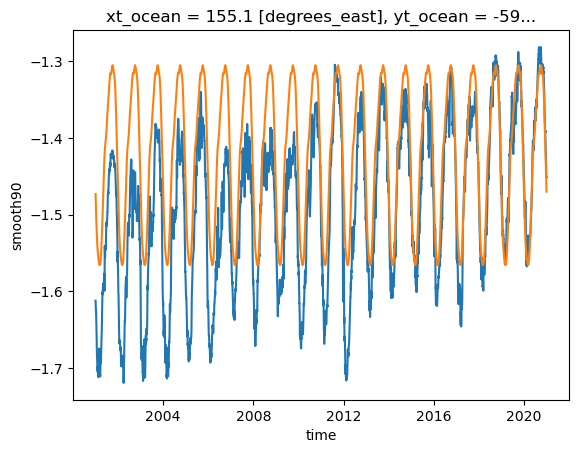

In [57]:
(sst_period*(-1)).plot()
expanded_threshold.plot()
result_ds.values

In [ ]:
client.close()